# Notebook — Mini-projet Bases IA (A* + Markov)

Ce notebook est **reproductible** et suit les expériences recommandées :

- **E1** : Comparer **UCS vs Greedy vs A*** sur 3 grilles (facile/moyenne/difficile)  
- **E2** : Fixer A* et varier **ε ∈ {0, 0.1, 0.2, 0.3}** : coût prévu (A*) vs probabilité réelle d'atteindre GOAL (Markov)  
- **E3** : Comparer deux heuristiques admissibles (**h=0** vs **Manhattan**) : expansions / temps  
- **E4 (option)** : Weighted A* : compromis vitesse vs optimalité  

> Prérequis : exécuter ce notebook depuis le dossier du projet (où se trouvent `astar.py`, `markov.py`, etc.).


In [1]:
import os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import astar as ast
from grid import Grid
from heuristics import h_zero, manhattan
from policy import policy_from_path
from markov import build_transition_matrix, absorbing_curves, pi_n, absorption_analysis
from simulation import monte_carlo

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

print("OK. Dossier results/ =", RESULTS.resolve())



OK. Dossier results/ = /home/douyry/Bureau/master sdia/projets/mini_projet_structure_prof_plus_notebook/mini_projet_prof_with_notebook/results


## 1) Génération des grilles (facile / moyenne / difficile)
Tu peux modifier les obstacles ici si tu veux reproduire les grilles de l'énoncé.


In [2]:
def make_grids():
    easy_obs = {(1,2),(2,2),(3,2),(3,3),(3,4)}
    medium_obs = {(r,5) for r in range(1,10)} | {(7,c) for c in range(2,11)} | {(3,9),(4,9),(5,9)}
    hard_obs = {(r,7) for r in range(0,14)} | {(10,c) for c in range(0,12)} | {(4,c) for c in range(8,15)}

    easy = Grid(rows=10, cols=10, obstacles=easy_obs, start=(0,0), goal=(9,9))
    medium = Grid(rows=12, cols=12, obstacles=medium_obs, start=(0,0), goal=(11,11))
    hard = Grid(rows=15, cols=15, obstacles=hard_obs, start=(0,0), goal=(14,14))
    return {"easy": easy, "medium": medium, "hard": hard}

grids = make_grids()
list(grids.keys()), grids["easy"]


(['easy', 'medium', 'hard'],
 Grid(rows=10, cols=10, obstacles={(1, 2), (3, 3), (3, 4), (2, 2), (3, 2)}, start=(0, 0), goal=(9, 9)))

## 2) E1 — Comparaison UCS vs Greedy vs A*
On mesure :
- coût final (optimal si A* avec heuristique admissible/cohérente)
- nombre d’expansions (nœuds développés)
- temps d’exécution


In [3]:
def run_E1(grids):
    rows = []
    for name, g in grids.items():
        r_ucs = ast.ucs(g)
        r_greedy = ast.greedy(g, h=manhattan)
        r_astar = ast.astar(g, h=manhattan)

        for algo, r in [("UCS", r_ucs), ("Greedy", r_greedy), ("A*", r_astar)]:
            rows.append((name, algo, r.success, r.cost, r.expansions, r.open_max, r.elapsed_ms))
    return rows

E1 = run_E1(grids)
E1


[('easy', 'UCS', True, 18.0, 94, 10, 0.6616150003537768),
 ('easy', 'Greedy', True, 18.0, 18, 17, 0.1394400005665375),
 ('easy', 'A*', True, 18.0, 94, 10, 0.6280399993556784),
 ('medium', 'UCS', True, 22.0, 123, 11, 1.2280649998501758),
 ('medium', 'Greedy', True, 22.0, 22, 21, 0.17983000088861445),
 ('medium', 'A*', True, 22.0, 113, 11, 0.8136200003718841),
 ('hard', 'UCS', False, inf, 70, 8, 0.45208499977889005),
 ('hard', 'Greedy', False, inf, 70, 14, 0.5485880001288024),
 ('hard', 'A*', False, inf, 70, 8, 0.5222599993430777)]

In [4]:
# Affichage "tableau" simple
print("grid, algo, success, cost, expansions, open_max, elapsed_ms")
for row in E1:
    print(*row, sep=", ")


grid, algo, success, cost, expansions, open_max, elapsed_ms
easy, UCS, True, 18.0, 94, 10, 0.6616150003537768
easy, Greedy, True, 18.0, 18, 17, 0.1394400005665375
easy, A*, True, 18.0, 94, 10, 0.6280399993556784
medium, UCS, True, 22.0, 123, 11, 1.2280649998501758
medium, Greedy, True, 22.0, 22, 21, 0.17983000088861445
medium, A*, True, 22.0, 113, 11, 0.8136200003718841
hard, UCS, False, inf, 70, 8, 0.45208499977889005
hard, Greedy, False, inf, 70, 14, 0.5485880001288024
hard, A*, False, inf, 70, 8, 0.5222599993430777


## 3) E3 — Heuristiques admissibles : h=0 vs Manhattan
On compare A* avec :
- h=0 (admissible mais peu informée) => proche UCS
- Manhattan (admissible + cohérente sur grille 4-voisins)


In [5]:
def run_E3(grid: Grid):
    r0 = ast.astar(grid, h=h_zero)
    rM = ast.astar(grid, h=manhattan)
    return r0, rM

r0, rM = run_E3(grids["hard"])
print("A* h=0:", r0)
print("A* Manhattan:", rM)


A* h=0: SearchResult(path=[], cost=inf, expansions=70, open_max=8, elapsed_ms=0.3041640002265922, success=False)
A* Manhattan: SearchResult(path=[], cost=inf, expansions=70, open_max=8, elapsed_ms=0.2712870000323164, success=False)


## 4) E2 — Markov : Construction de P, calculs P^n et π(n), impact de ε

On fixe une politique induite par A* puis on construit la chaîne de Markov :

- action prévue : probabilité (1-ε)
- déviation gauche : ε/2
- déviation droite : ε/2

Option : état absorbant FAIL + collision -> FAIL.


In [6]:
grid = grids["medium"]

# 1) Plan déterministe (A*)
res = ast.astar(grid, h=manhattan)
assert res.success, "A* n'a pas trouvé de chemin sur cette grille."
policy = policy_from_path(res.path)

print("Coût prévu A* =", res.cost, " | longueur chemin =", len(res.path)-1)


Coût prévu A* = 22.0  | longueur chemin = 22


In [7]:
eps_list = [0.0, 0.1, 0.2, 0.3]
horizon = 60

E2_rows = []
curves_by_eps = {}

for eps in eps_list:
    mm = build_transition_matrix(grid, policy, epsilon=eps, add_fail=True, collision_to_fail=True)

    # Vérification stochastique : somme des lignes = 1
    row_sums = mm.P.sum(axis=1)
    max_err = float(np.max(np.abs(row_sums - 1.0)))
    print(f"ε={eps} | |S|={mm.P.shape[0]} | max|sum(row)-1|={max_err:.2e}")

    curves = absorbing_curves(mm, grid.start, horizon=horizon)
    curves_by_eps[eps] = curves

    # Monte-Carlo pour cohérence
    mc = monte_carlo(mm, grid.start, episodes=3000, max_steps=300, seed=0)

    E2_rows.append({
        "eps": eps,
        "cost_astar": res.cost,
        "p_goal_final": float(curves["goal"][-1]),
        "p_fail_final": float(curves["fail"][-1]),
        "mc_success": mc.success_rate,
        "mc_fail": mc.fail_rate,
        "mc_mean_steps": mc.mean_steps_all,
    })

E2_rows


ε=0.0 | |S|=125 | max|sum(row)-1|=0.00e+00
ε=0.1 | |S|=125 | max|sum(row)-1|=0.00e+00
ε=0.2 | |S|=125 | max|sum(row)-1|=0.00e+00
ε=0.3 | |S|=125 | max|sum(row)-1|=0.00e+00


[{'eps': 0.0,
  'cost_astar': 22.0,
  'p_goal_final': 1.0,
  'p_fail_final': 0.0,
  'mc_success': 1.0,
  'mc_fail': 0.0,
  'mc_mean_steps': 22.0},
 {'eps': 0.1,
  'cost_astar': 22.0,
  'p_goal_final': 0.10311737195639918,
  'p_fail_final': 0.4566562510922194,
  'mc_success': 0.10133333333333333,
  'mc_fail': 0.46,
  'mc_mean_steps': 137.40133333333333},
 {'eps': 0.2,
  'cost_astar': 22.0,
  'p_goal_final': 0.00802032351030852,
  'p_fail_final': 0.5006582809578896,
  'mc_success': 0.007,
  'mc_fail': 0.48933333333333334,
  'mc_mean_steps': 153.656},
 {'eps': 0.3,
  'cost_astar': 22.0,
  'p_goal_final': 0.00043685151380815437,
  'p_fail_final': 0.5014385519606936,
  'mc_success': 0.001,
  'mc_fail': 0.48433333333333334,
  'mc_mean_steps': 156.06766666666667}]

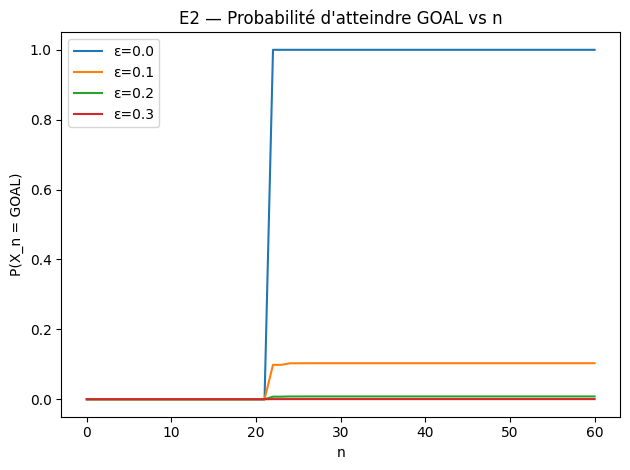

In [8]:
# Plot : P(GOAL) vs n pour chaque ε
x = np.arange(0, horizon+1)
plt.figure()
for eps in eps_list:
    plt.plot(x, curves_by_eps[eps]["goal"], label=f"ε={eps}")
plt.xlabel("n")
plt.ylabel("P(X_n = GOAL)")
plt.title("E2 — Probabilité d'atteindre GOAL vs n")
plt.legend()
plt.tight_layout()
plt.show()


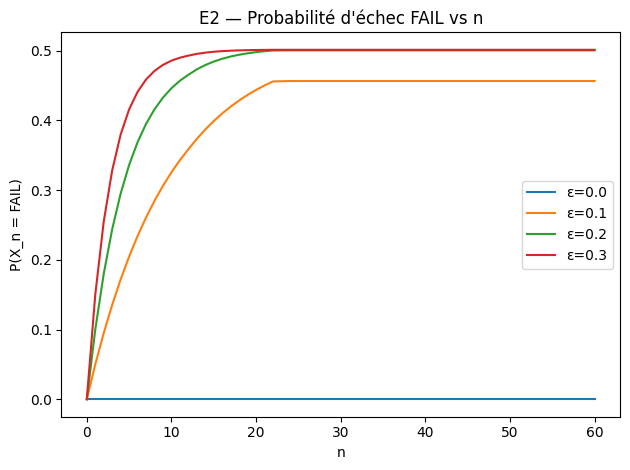

In [9]:
# Plot : P(FAIL) vs n pour chaque ε
plt.figure()
for eps in eps_list:
    plt.plot(x, curves_by_eps[eps]["fail"], label=f"ε={eps}")
plt.xlabel("n")
plt.ylabel("P(X_n = FAIL)")
plt.title("E2 — Probabilité d'échec FAIL vs n")
plt.legend()
plt.tight_layout()
plt.show()


### Exemple : calcul explicite π(n)=π(0)P^n

On affiche π(n) pour un n choisi, et on vérifie que la somme vaut 1.


In [13]:
eps = 0.2
mm = build_transition_matrix(grid, policy, epsilon=eps, add_fail=True, collision_to_fail=True)

n = 20
pi = pi_n(mm, grid.start, n)

print("Somme(pi) =", float(pi.sum()))
print("P(GOAL) =", float(pi[mm.goal_index]))
print("P(FAIL) =", float(pi[mm.fail_index]))


Somme(pi) = 1.0000000000000004
P(GOAL) = 0.0
P(FAIL) = 0.4980803296637173


## 5) Absorption (option)

Si on veut aller plus loin (option), on peut analyser la chaîne absorbante via la forme canonique :

\[
P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}
\]

- \(Q\) : transitions entre états transients
- \(R\) : transitions transients -> absorbants
- \(N = (I-Q)^{-1}\) : matrice fondamentale

> Ici on extrait Q, R et N (si inversible).


In [11]:
abs_data = absorption_analysis(mm)
Q, R, N = abs_data["Q"], abs_data["R"], abs_data["N"]
singular = int(abs_data["singular"][0])
print("Q shape:", Q.shape)
print("R shape:", R.shape)
print("N shape:", N.shape, "| singular(I-Q) =", singular)

# Temps moyen d'absorption depuis un état transient i: t = N @ 1
if N.size:
    ones = np.ones((N.shape[0],), dtype=float)
    t = N @ ones
    start_i = mm.idx[grid.start]
    transient_idx = abs_data["transient_idx"]
    if start_i in transient_idx.tolist():
        k = int(np.where(transient_idx == start_i)[0][0])
        print("Temps moyen d'absorption depuis START ≈", float(t[k]))


Q shape: (123, 123)
R shape: (123, 2)
N shape: (123, 123) | singular(I-Q) = 1
Temps moyen d'absorption depuis START ≈ 4.403691470377506


## 6) E4 (option) — Weighted A*

On teste plusieurs poids w :
- w=1.0 : A*
- w>1 : accélération possible mais perte d'optimalité


In [12]:
weights = [1.0, 1.5, 2.0]
rows = []
for w in weights:
    r = ast.weighted_astar(grid, w=w, h=manhattan)
    rows.append((w, r.success, r.cost, r.expansions, r.elapsed_ms))
rows


[(1.0, True, 22.0, 113, 0.5135779992997414),
 (1.5, True, 22.0, 22, 0.10515899975871434),
 (2.0, True, 22.0, 22, 0.10119000035047065)]